In [4]:
import pandas as pd

classification_df = pd.read_csv('data/diabetes_three_category.csv')

# show unique values for each column
for col in classification_df.columns:
    print(f"{col}: {classification_df[col].unique()}")

Diabetes_012: [0. 2. 1.]
HighBP: [1. 0.]
HighChol: [1. 0.]
CholCheck: [1. 0.]
BMI: [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Smoker: [1. 0.]
Stroke: [0. 1.]
HeartDiseaseorAttack: [0. 1.]
PhysActivity: [0. 1.]
Fruits: [0. 1.]
Veggies: [1. 0.]
HvyAlcoholConsump: [0. 1.]
AnyHealthcare: [1. 0.]
NoDocbcCost: [0. 1.]
GenHlth: [5. 3. 2. 4. 1.]
MentHlth: [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
PhysHlth: [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]
DiffWalk: [1. 0.]
Sex: [0. 1.]
Age: [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3

In [5]:
binary_df = pd.read_csv('data/diabetes_two_category.csv')
binary_df.head()
binary_df.columns





Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [6]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# prep data 
classification_df = classification_df.sample(frac=1, random_state=42).reset_index(drop=True)
binary_df = binary_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Standard scaling before PCA for classification_df
features_class = classification_df.loc[:, classification_df.columns != 'Diabetes_012']
target_class = classification_df['Diabetes_012']
scaler_class = StandardScaler()
features_class_scaled = scaler_class.fit_transform(features_class)
pca_class = PCA(n_components=10, random_state=42)
features_class_pca = pca_class.fit_transform(features_class_scaled)
classification_df_pca = pd.DataFrame(features_class_pca)
classification_df_pca['Diabetes_012'] = target_class.values

# Standard scaling before PCA for binary_df
features_bin = binary_df.loc[:, binary_df.columns != 'Diabetes_binary']
target_bin = binary_df['Diabetes_binary']
scaler_bin = StandardScaler()
features_bin_scaled = scaler_bin.fit_transform(features_bin)
pca_bin = PCA(n_components=10, random_state=42)
features_bin_pca = pca_bin.fit_transform(features_bin_scaled)
binary_df_pca = pd.DataFrame(features_bin_pca)
binary_df_pca['Diabetes_binary'] = target_bin.values

# set aside 10% of data for part B
bin_train, bin_test = train_test_split(binary_df_pca, test_size=0.1, random_state=42)
class_train, class_test = train_test_split(classification_df_pca, test_size=0.1, random_state=42)

# split into 4 sets
classification_sets = [df.reset_index(drop=True) for df in np.array_split(class_train, 4)]
binary_sets = [df.reset_index(drop=True) for df in np.array_split(bin_train, 4)]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

c_svm_df = classification_sets[3]
b_svm_df = binary_sets[3]

##RUN SVM MULTI

In [7]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

kernel = ['linear', 'poly', 'rbf']   # hyperparameter to tune
svm_class_accuracies = {}             # store fold accuracies for each kernel
svm_class_means = {}         

X_class = c_svm_df.loc[:, c_svm_df.columns != 'Diabetes_012']
y_class = c_svm_df['Diabetes_012']

for ker in kernel:
        accuracies_list = []
        print(f"\n### Kernel = {ker}")
        fold_scores = []
        for i, (train, test) in enumerate(kf.split(X_class, y_class)):
            print(f"\nFold {i+1}")
            print("TRAIN indices:", train)
            print("TEST indices:", test)

            X_train = X_class.iloc[train]
            y_train = y_class.iloc[train]
            X_test  = X_class.iloc[test]
            y_test  = y_class.iloc[test]

            svm_clf = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel=ker, random_state=42))
        ])
            svm_clf.fit(X_train, y_train)
            score = svm_clf.score(X_test, y_test)
            print(f"Accuracy with kernel={ker} on this fold: {score:.4f}")
            fold_scores.append(score)

        svm_class_accuracies[ker] = fold_scores
        svm_class_means[ker] = np.mean(fold_scores)
        print(f"\nMean CV accuracy for kernel={ker}: {svm_class_means[ker]:.4f}")




### Kernel = linear

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy with kernel=linear on this fold: 0.8462

Fold 2
TRAIN indices: [    2     3     4 ... 57075 57076 57077]
TEST indices: [    0     1     7 ... 57061 57063 57067]
Accuracy with kernel=linear on this fold: 0.8437

Fold 3
TRAIN indices: [    0     1     2 ... 57071 57074 57077]
TEST indices: [    3     8    14 ... 57073 57075 57076]
Accuracy with kernel=linear on this fold: 0.8437

Fold 4
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    5    15    18 ... 57058 57069 57071]
Accuracy with kernel=linear on this fold: 0.8427

Fold 5
TRAIN indices: [    0     1     3 ... 57073 57075 57076]
TEST indices: [    2     9    10 ... 57060 57074 57077]
Accuracy with kernel=linear on this fold: 0.8443

Mean CV accuracy for kernel=linear: 0.8441

### Kernel = poly

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
T

## RUN BINARY

In [8]:
# X and y for binary classification
X_bin = b_svm_df.loc[:, b_svm_df.columns != 'Diabetes_binary']
y_bin = b_svm_df['Diabetes_binary']

kernels = ['linear', 'poly', 'rbf']
svm_bin_accuracies = {}
svm_bin_means = {}

for ker in kernels:
    print(f"\n### Kernel = {ker}")
    fold_scores = []

    for i, (train_idx, test_idx) in enumerate(kf.split(X_bin, y_bin)):
        print(f"\nFold {i+1}")
        print("TRAIN indices:", train_idx)
        print("TEST indices:", test_idx)

        X_train = X_bin.iloc[train_idx]
        y_train = y_bin.iloc[train_idx]
        X_test  = X_bin.iloc[test_idx]
        y_test  = y_bin.iloc[test_idx]

        svm_clf = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel=ker, random_state=42))
        ])

        svm_clf.fit(X_train, y_train)
        score = svm_clf.score(X_test, y_test)
        print(f"Accuracy with kernel={ker} on this fold: {score:.4f}")
        fold_scores.append(score)

    svm_bin_accuracies[ker] = fold_scores
    svm_bin_means[ker] = np.mean(fold_scores)
    print(f"\nMean CV accuracy for kernel={ker}: {svm_bin_means[ker]:.4f}")



### Kernel = linear

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy with kernel=linear on this fold: 0.8628

Fold 2
TRAIN indices: [    2     3     4 ... 57075 57076 57077]
TEST indices: [    0     1     7 ... 57061 57063 57067]
Accuracy with kernel=linear on this fold: 0.8634

Fold 3
TRAIN indices: [    0     1     2 ... 57071 57074 57077]
TEST indices: [    3     8    14 ... 57073 57075 57076]
Accuracy with kernel=linear on this fold: 0.8601

Fold 4
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    5    15    18 ... 57058 57069 57071]
Accuracy with kernel=linear on this fold: 0.8624

Fold 5
TRAIN indices: [    0     1     3 ... 57073 57075 57076]
TEST indices: [    2     9    10 ... 57060 57074 57077]
Accuracy with kernel=linear on this fold: 0.8622

Mean CV accuracy for kernel=linear: 0.8622

### Kernel = poly

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
T

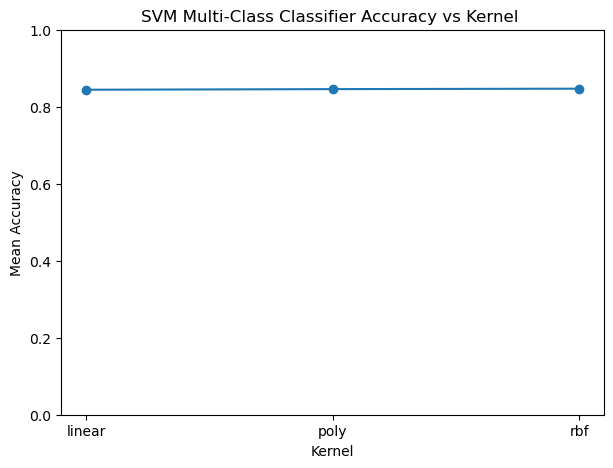

In [9]:
import matplotlib.pyplot as plt

# Choose which dict you want to plot:
# svm_class_means  or  svm_bin_means
kernel_means = svm_class_means  # ← swap if needed

# Extract for plotting
kernels = list(kernel_means.keys())
mean_scores = list(kernel_means.values())

plt.figure(figsize=(7,5))
plt.plot(kernels, mean_scores, marker="o")
plt.title("SVM Multi-Class Classifier Accuracy vs Kernel ")
plt.xlabel("Kernel")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)


plt.show()


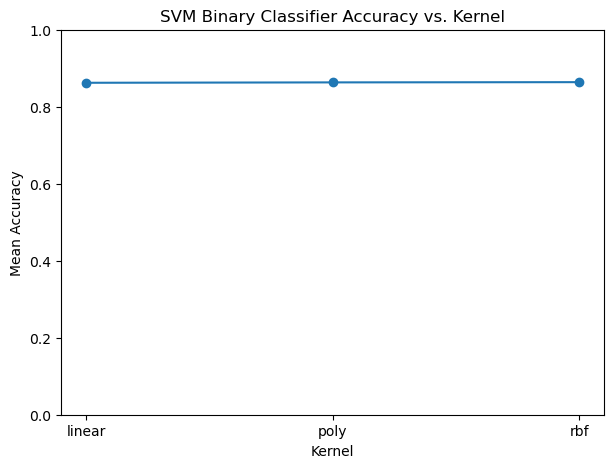

In [10]:
import matplotlib.pyplot as plt

# Choose which dict you want to plot:
# svm_class_means  or  svm_bin_means
kernel_means = svm_bin_means  # ← swap if needed

# Extract for plotting
kernels = list(kernel_means.keys())
mean_scores = list(kernel_means.values())

plt.figure(figsize=(7,5))
plt.plot(kernels, mean_scores, marker="o")
plt.title("SVM Binary Classifier Accuracy vs. Kernel")
plt.xlabel("Kernel")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)


plt.show()
